In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('Jarvis_Intent_Dataset5.csv')

data

,text,intent
0,hello,greeting
1,hi,greeting
2,hey,greeting
3,hey jarvis,greeting
4,hello assistant,greeting
...,...,...
637,find pptx file,ppt_search
638,search pptx,ppt_search
639,locate pptx file,ppt_search
640,find my pptx,ppt_search


In [3]:
df = data.copy()

df.sample(5)

,text,intent
255,last copied item,clipboard_read
192,launch file explorer,open_app
592,open presentation,ppt_search
279,how much disk space do i have,disk_status
435,secure the workstation,lock_screen


In [4]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text

df["text"] = df["text"].apply(clean_text)

In [5]:
df['intent'].unique()

array(['greeting', 'open_app', 'battery_status', 'brightness_control',
       'clipboard_read', 'date_time', 'disk_status', 'doc_search',
       'pdf_search', 'image_search', 'folder_search', 'internet_speed',
       'ip_address', 'lock_screen', 'media_control', 'open_website',
       'quit', 'restart_pc', 'shutdown_pc', 'screenshot', 'system_status',
       'system_uptime', 'volume_control', 'wifi_status', 'ppt_search'],
      dtype=object)

In [6]:
print(df["intent"].value_counts())

intent
ppt_search            57
greeting              45
battery_status        25
open_app              25
screenshot            25
shutdown_pc           25
restart_pc            25
quit                  25
open_website          25
media_control         25
brightness_control    25
lock_screen           25
internet_speed        25
folder_search         25
image_search          25
pdf_search            25
doc_search            25
disk_status           25
date_time             25
clipboard_read        25
ip_address            25
volume_control        20
system_status         16
wifi_status           15
system_uptime         14
Name: count, dtype: int64


## Splitting into X and y

In [7]:
X = df['text']
y = df['intent']

print(X[:5])
print(y[:100:20])

0              hello
1                 hi
2                hey
3         hey jarvis
4    hello assistant
Name: text, dtype: object
0           greeting
20    battery_status
40         date_time
60      image_search
80       lock_screen
Name: intent, dtype: object


## Convert Text → Numbers (TF-IDF)
`This converts text into ML understandable format`

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=1,          # was 2 — too aggressive for small data
    max_df=0.95,
)

X_vectorized = vectorizer.fit_transform(X)
print(X_vectorized.shape) 

(642, 1312)


## Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=1)

print(X_train.shape)
print(y_train.shape)

(513, 1312)
(513,)


## Model Training
1. `Logistic Regression`
2. `Linear SVC`

In [11]:
from sklearn.linear_model import LogisticRegression

model_logistic_regression = LogisticRegression(max_iter=1000)

model_logistic_regression.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
from sklearn.svm import LinearSVC

model_linear_SVC = LinearSVC(C=1.5, class_weight='balanced')
model_linear_SVC.fit(X_train, y_train)

LinearSVC(C=1.5, class_weight='balanced')

## Accuracy testing

In [13]:
accuracy_logistic_regression = model_logistic_regression.score(X_test, y_test)
print(f"Accuracy of Logistic Regression = {accuracy_logistic_regression}")

accuracy_linear_SVC = model_linear_SVC.score(X_test, y_test)
print(f"Accuracy of Linear SVC = {accuracy_linear_SVC}")

Accuracy of Logistic Regression = 0.7286821705426356
Accuracy of Linear SVC = 0.8527131782945736


## Test with custom input

In [14]:
def predict_intent(text):
    text_vector = vectorizer.transform([text])
    prediction = model_linear_SVC.predict(text_vector)
    return prediction[0]


print(predict_intent("open youtube"))
print(predict_intent("find resume pdf"))
print(predict_intent("increase volume"))

open_website
pdf_search
volume_control


In [15]:
print(predict_intent("hey Buddy"))

greeting


In [16]:
print(predict_intent("Search earth on google"))

open_website


In [17]:
print(predict_intent("wifi status"))

wifi_status


In [18]:
print(predict_intent("system uptime"))

system_uptime


In [19]:
print(predict_intent("how long the system is running"))

system_uptime


In [20]:
print(predict_intent("thank you"))

greeting


## Model Saving

In [21]:
import pickle

# save model
with open("intent_model3.pkl", "wb") as f:
    pickle.dump(model_linear_SVC, f)

# save vectorizer
with open("vectorizer3.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


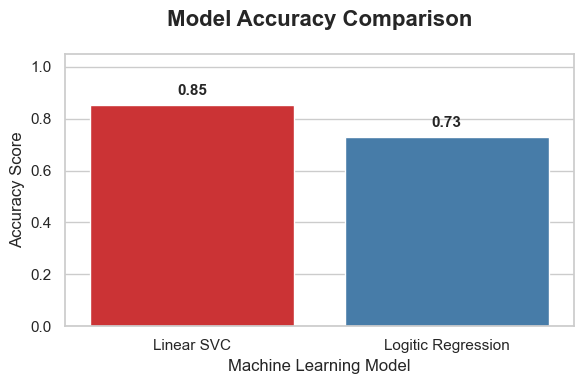

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Organize data into a DataFrame and sort by accuracy
data = {
    'Model': ['Logitic Regression', 'Linear SVC'],
    'Accuracy': [accuracy_logistic_regression, accuracy_linear_SVC]
}
df = pd.DataFrame(data).sort_values(by='Accuracy', ascending=False)

# 2. Set a clean aesthetic style
sns.set_theme(style="whitegrid")

# 3. Create the plot using subplots for better control
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x='Model', y='Accuracy', data=df, palette='Set1', ax=ax)

# 4. Add professional titles and labels
ax.set_title('Model Accuracy Comparison', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Machine Learning Model', fontsize=12)
ax.set_ylabel('Accuracy Score', fontsize=12)
ax.set_ylim(0, 1.05)  # Scale from $0$ to $1$ with extra space for labels

# 5. Add text labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png')